# Benchmark — Telco Customer Churn

## 1. Navázání na DÚ1 a dataprocessing

**Business problém:** Výběr rizikových zákazníků pro retenční zásah při omezeném budgetu.

**Typ úlohy:** Binární klasifikace — model odhaduje pravděpodobnost churnu (0–1).

**Cílová proměnná:** Churn (1 = odešel, 0 = zůstal)

**Primární metrika:** F1-score  
**Doplňkové metriky:** ROC-AUC, PR-AUC

**Benchmarky v tomto notebooku:**
1. Naivní baseline — pravidlové řešení: Contract = Month-to-month AND tenure ≤ 12
2. ML benchmark — logistická regrese s class_weight="balanced"

**Vyhodnocení:** výhradně na validační sadě. Testovací sada zůstává uzamčena.

**Návaznost:** Data připravena v dataprocessing.ipynb a načtena z uložených CSV souborů.

## 2. Načtení dat

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

RANDOM_STATE = 42

In [2]:
# Načtení zpracovaných dat pro ML benchmark (logistická regrese)
train_proc = pd.read_csv("data/processed/train_processed.csv")
val_proc = pd.read_csv("data/processed/validation_processed.csv")

# Oddělení features a targetu
X_train = train_proc.drop(columns=["Churn"])
y_train = train_proc["Churn"]
X_val = val_proc.drop(columns=["Churn"])
y_val = val_proc["Churn"]

print(f"Train (processed): {X_train.shape}")
print(f"Validation (processed): {X_val.shape}")

Train (processed): (5625, 22)
Validation (processed): (1055, 22)


In [3]:
# Načtení pre-processed dat pro pravidlový baseline (původní hodnoty tenure a Contract)
train_raw = pd.read_csv("data/pre-processed/train.csv")
val_raw = pd.read_csv("data/pre-processed/validation.csv")

print(f"Train (pre-processed): {train_raw.shape}")
print(f"Validation (pre-processed): {val_raw.shape}")

# Ověření, že target je konzistentní mezi pre-processed a processed verzí
assert (y_train.values == train_raw["Churn"].values).all(), "Nesoulad targetu train!"
assert (y_val.values == val_raw["Churn"].values).all(), "Nesoulad targetu validation!"
print("\n→ Target konzistentní mezi pre-processed a processed verzí.")

Train (pre-processed): (5625, 20)
Validation (pre-processed): (1055, 20)

→ Target konzistentní mezi pre-processed a processed verzí.


## 3. Naivní baseline — pravidlové řešení

**Pravidlo:** Zákazník s Contract = Month-to-month AND tenure ≤ 12 měsíců je označen jako rizikový (Churn = 1), jinak Churn = 0.

**Zdůvodnění:** Pravidlo odpovídá základní business intuici z DÚ1 — zákazníci s měsíční smlouvou a krátkým vztahem ještě nevybudovali loajalitu a mají nejvyšší míru odchodu. Slouží jako odpověď na otázku: překoná ML model jednoduché lidské pravidlo?

Baseline je vyhodnocen na raw datech, protože pravidlo pracuje s původními hodnotami tenure a Contract.

In [4]:
# Pravidlový baseline: Contract = Month-to-month AND tenure ≤ 12
y_pred_rule = (
    (val_raw["Contract"] == "Month-to-month") & (val_raw["tenure"] <= 12)
).astype(int)

# Kolik zákazníků pravidlo označí jako rizikových
print(f"Pravidlem označeno jako rizikových: {y_pred_rule.sum()} z {len(y_pred_rule)}")
print(f"Podíl označených: {y_pred_rule.mean()*100:.1f} %")

Pravidlem označeno jako rizikových: 272 z 1055
Podíl označených: 25.8 %


In [5]:
# Vyhodnocení pravidlového baseline na validační sadě
print("=== PRAVIDLOVÝ BASELINE ===\n")

f1_rule = f1_score(y_val, y_pred_rule)
print(f"F1-score:  {f1_rule:.3f}")

# Pravidlo nemá pravděpodobnostní výstup — ROC-AUC a PR-AUC počítáme z binární predikce
roc_rule = roc_auc_score(y_val, y_pred_rule)
pr_rule = average_precision_score(y_val, y_pred_rule)
print(f"ROC-AUC:   {roc_rule:.3f}")
print(f"PR-AUC:    {pr_rule:.3f}")

print(f"\nClassification report:")
print(classification_report(y_val, y_pred_rule, target_names=["No", "Yes"]))

=== PRAVIDLOVÝ BASELINE ===

F1-score:  0.533
ROC-AUC:   0.682
PR-AUC:    0.410

Classification report:
              precision    recall  f1-score   support

          No       0.83      0.84      0.83       775
         Yes       0.54      0.53      0.53       280

    accuracy                           0.76      1055
   macro avg       0.69      0.68      0.68      1055
weighted avg       0.75      0.76      0.75      1055



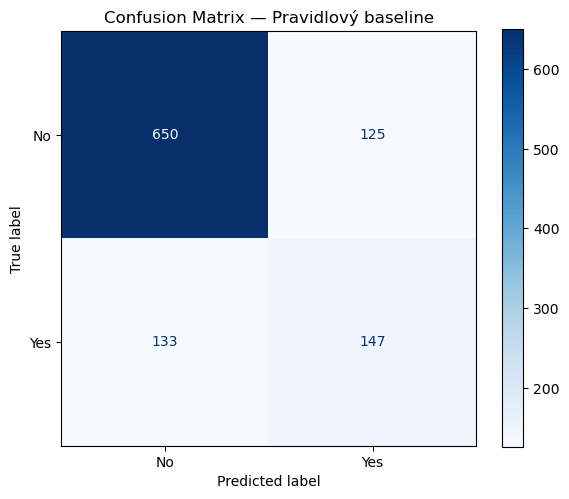

In [6]:
# Confusion matrix pravidlového baseline
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_rule, display_labels=["No", "Yes"], ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix — Pravidlový baseline")
plt.tight_layout()
plt.show()

## 4. ML benchmark — Logistická regrese

**Model:** Logistická regrese s class_weight="balanced" pro kompenzaci nevyvážených tříd.

**Zdůvodnění:** Logistická regrese je interpretovatelný model vhodný jako první ML benchmark pro binární klasifikaci na tabulkových datech. Vrací přímo pravděpodobnosti, což umožňuje smysluplné vyhodnocení ROC-AUC a PR-AUC. Parametr class_weight="balanced" automaticky zvýší váhu menšinové třídy (churn) a sníží váhu majoritní třídy.

Složitější modely (např. Random Forest, XGBoost aj.) musí v dalších úkolech tuto hranici smysluplně překročit!

In [7]:
# Logistická regrese s vyváženými váhami tříd
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Fit na trénovací sadě
lr.fit(X_train, y_train)

# Predikce na validační sadě — třídy i pravděpodobnosti
y_pred_lr = lr.predict(X_val)
y_proba_lr = lr.predict_proba(X_val)[:, 1]

print("Logistická regrese natrénována.")
print(f"Počet iterací: {lr.n_iter_[0]}")

Logistická regrese natrénována.
Počet iterací: 23


In [8]:
# Vyhodnocení logistické regrese na validační sadě
print("=== LOGISTICKÁ REGRESE ===\n")

f1_lr = f1_score(y_val, y_pred_lr)
roc_lr = roc_auc_score(y_val, y_proba_lr)
pr_lr = average_precision_score(y_val, y_proba_lr)

print(f"F1-score:  {f1_lr:.3f}")
print(f"ROC-AUC:   {roc_lr:.3f}")
print(f"PR-AUC:    {pr_lr:.3f}")

print(f"\nClassification report:")
print(classification_report(y_val, y_pred_lr, target_names=["No", "Yes"]))

=== LOGISTICKÁ REGRESE ===

F1-score:  0.639
ROC-AUC:   0.843
PR-AUC:    0.633

Classification report:
              precision    recall  f1-score   support

          No       0.91      0.76      0.82       775
         Yes       0.54      0.79      0.64       280

    accuracy                           0.76      1055
   macro avg       0.72      0.77      0.73      1055
weighted avg       0.81      0.76      0.78      1055



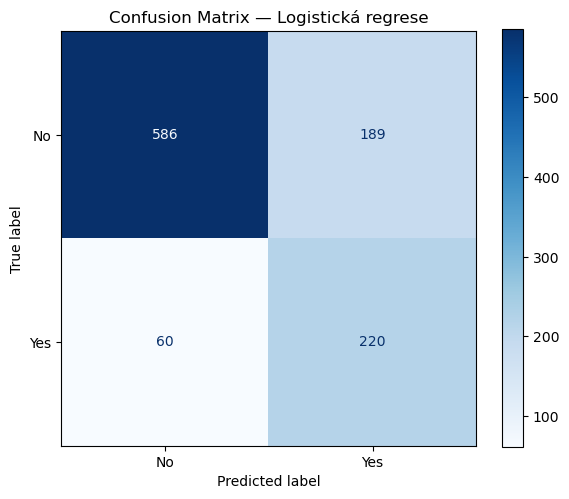

In [9]:
# Confusion matrix logistické regrese
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_lr, display_labels=["No", "Yes"], ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix — Logistická regrese")
plt.tight_layout()
plt.show()

Top 10 nejsilnějších proměnných (absolutní hodnota koeficientu):

                      Proměnná  Koeficient
                        tenure   -1.333056
                      Contract   -0.747576
                  PhoneService   -0.740501
            InternetService_No   -0.643708
                  TotalCharges    0.614624
   InternetService_Fiber optic    0.564288
                OnlineSecurity   -0.394874
                   TechSupport   -0.343204
PaymentMethod_Electronic check    0.332592
              PaperlessBilling    0.284054


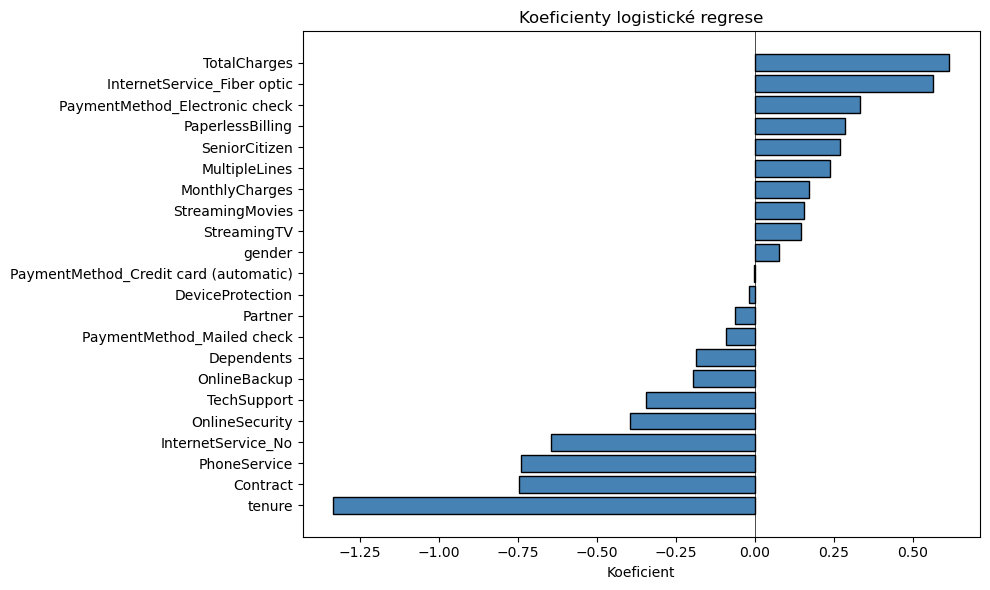

In [10]:
# Koeficienty logistické regrese — interpretace vlivu proměnných
coef_df = pd.DataFrame({
    "Proměnná": X_train.columns,
    "Koeficient": lr.coef_[0]
}).sort_values("Koeficient", key=abs, ascending=False)

print("Top 10 nejsilnějších proměnných (absolutní hodnota koeficientu):\n")
print(coef_df.head(10).to_string(index=False))

# Vizualizace
fig, ax = plt.subplots(figsize=(10, 6))
coef_df_sorted = coef_df.sort_values("Koeficient")
ax.barh(coef_df_sorted["Proměnná"], coef_df_sorted["Koeficient"], color="steelblue", edgecolor="black")
ax.set_title("Koeficienty logistické regrese")
ax.set_xlabel("Koeficient")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 5. Porovnání benchmarků

In [11]:
# Souhrnná tabulka výsledků benchmarků na validační sadě
vysledky = pd.DataFrame({
    "Benchmark": ["Pravidlový baseline", "Logistická regrese"],
    "F1-score": [f1_rule, f1_lr],
    "ROC-AUC": [roc_rule, roc_lr],
    "PR-AUC": [pr_rule, pr_lr]
}).round(3)

print("=== POROVNÁNÍ BENCHMARKŮ (validační sada) ===\n")
print(vysledky.to_string(index=False))

=== POROVNÁNÍ BENCHMARKŮ (validační sada) ===

          Benchmark  F1-score  ROC-AUC  PR-AUC
Pravidlový baseline     0.533    0.682   0.410
 Logistická regrese     0.639    0.843   0.633


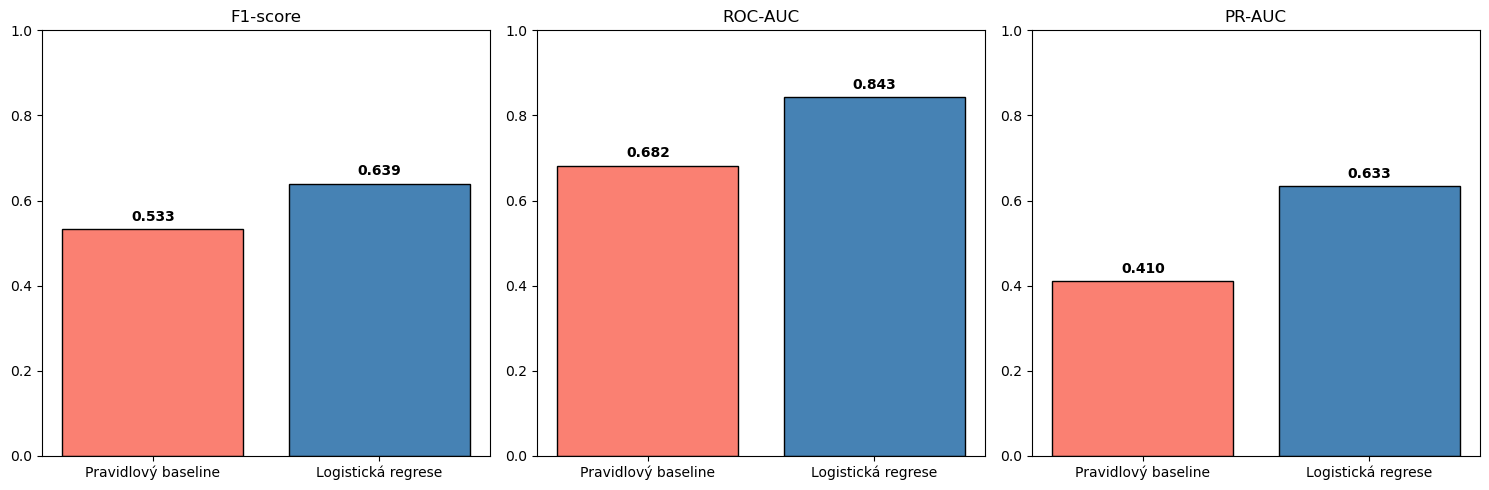

In [12]:
# Vizuální porovnání metrik
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metriky = ["F1-score", "ROC-AUC", "PR-AUC"]
barvy = ["salmon", "steelblue"]

for ax, metrika in zip(axes, metriky):
    hodnoty = vysledky[metrika].values
    ax.bar(vysledky["Benchmark"], hodnoty, color=barvy, edgecolor="black")
    ax.set_title(metrika)
    ax.set_ylim(0, 1)
    # Hodnoty nad sloupci
    for i, v in enumerate(hodnoty):
        ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 6. Shrnutí a další kroky

### Výsledky

Logistická regrese překonává pravidlový baseline ve všech třech metrikách. Pravidlový baseline slouží jako důkaz, že ML model přidává hodnotu oproti jednoduché business intuici.

### Metodické poznámky

- Oba benchmarky byly vyhodnoceny **výhradně na validační sadě** — testovací sada zůstává uzamčena.
- Pravidlový baseline byl vyhodnocen na raw datech (původní hodnoty tenure a Contract), logistická regrese na processed datech (po encodingu a scalingu).
- Konzistence targetu mezi raw a processed verzí byla ověřena assertem.
- Logistická regrese s class_weight="balanced" automaticky kompenzuje nevyváženost tříd.

### Interpretace koeficientů

Koeficienty logistické regrese ukazují, které proměnné mají nejsilnější asociaci s churnem. Záporné koeficienty (např. tenure, Contract) snižují pravděpodobnost odchodu — delší vztah a dlouhodobější smlouva jsou asociovány s nižším churnem. Kladné koeficienty (např. MonthlyCharges) zvyšují pravděpodobnost odchodu.

### Další kroky (HW3+)

1. **Pokročilé modely:** Random Forest, XGBoost / LightGBM
2. **Kalibrace pravděpodobností:** Platt scaling / isotonic regression
3. **Cost-sensitive hodnocení:** asymetrie nákladů FN vs. FP, optimalizace prahu
4. **Top-K selection:** Precision@K pro simulaci omezeného retenčního budgetu
5. **Interpretace:** SHAP hodnoty, permutation importance